# 01 — Nghiên cứu và Xử lý Outlier & Noise (Wine Reviews 130k)

Notebook này thực hiện chuyên sâu nhiệm vụ **Phát hiện, Đánh giá và Xử lý Outlier & Noise** trên tập dữ liệu `winemag-data-130k-v2.csv`.

### Nội dung chính:
1. **Phân tích Outlier đơn biến (`price`)**: Thống kê Tukey Boxplot, IQR, phân loại Natural Outliers vs Artificial Outliers.
2. **Phân tích Outlier đa biến (`points` vs `price`)**: Tương quan điểm số và giá bán, phát hiện bất thường.
3. **Phân tích và Khử Noise**: Xử lý HTML entities, ký tự ẩn `\xa0`, lọc review rác/siêu ngắn, khử nhiễu năm thành lập hãng khi trích xuất niên vụ.
4. **Biến đổi Log-transform & So sánh Before/After**: Đưa phân phối lệch phải (skewness 18.0) về gần phân phối chuẩn (skewness 0.65) phục vụ Machine Learning.

## 1. Nạp thư viện và dữ liệu

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import html
import re

# Thiết lập giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 5)

# Xác định đường dẫn tương đối linh hoạt
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / 'data' / 'interim' / '03_duplicates_handled.csv'
if not DATA_PATH.exists():
    raise FileNotFoundError('Hãy chạy python src/pipeline.py trước để tạo dữ liệu interim.')
df = pd.read_csv(DATA_PATH)
print(f"Nạp thành công dataset: {df.shape[0]:,} dòng × {df.shape[1]} cột")

Nạp thành công dataset: 119,988 dòng × 13 cột


## 2. Phân tích Thống kê & Phát hiện Outlier trên Cột `price`

Chúng ta áp dụng quy tắc phân vị Tukey (IQR rule) để phân loại Outlier.

In [2]:
prices = df['price'].dropna()
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
iqr = q3 - q1
mild_threshold = q3 + 1.5 * iqr
extreme_threshold = q3 + 3.0 * iqr

print(f"=== THỐNG KÊ PHÂN PHỐI GIÁ (USD) ===")
print(f"Số dòng có giá hợp lệ : {len(prices):,}")
print(f"Q1 (25%)              : {q1:.1f} USD")
print(f"Median (50%)          : {prices.median():.1f} USD")
print(f"Q3 (75%)              : {q3:.1f} USD")
print(f"IQR (Q3 - Q1)         : {iqr:.1f} USD")
print(f"Mean ± Std            : {prices.mean():.2f} ± {prices.std():.2f} USD")
print(f"Min - Max             : {prices.min():.1f} - {prices.max():.1f} USD")
print(f"Độ lệch (Skewness)    : {prices.skew():.2f}")
print(f"\nNgưỡng Mild Outlier (> {mild_threshold:.1f}$): {(prices > mild_threshold).sum():,} dòng ({(prices > mild_threshold).mean()*100:.2f}%)")
print(f"Ngưỡng Extreme Outlier (> {extreme_threshold:.1f}$): {(prices > extreme_threshold).sum():,} dòng ({(prices > extreme_threshold).mean()*100:.2f}%)")

=== THỐNG KÊ PHÂN PHỐI GIÁ (USD) ===
Số dòng có giá hợp lệ : 119,988
Q1 (25%)              : 17.0 USD
Median (50%)          : 25.0 USD
Q3 (75%)              : 42.0 USD
IQR (Q3 - Q1)         : 25.0 USD
Mean ± Std            : 35.14 ± 40.79 USD
Min - Max             : 4.0 - 3300.0 USD
Độ lệch (Skewness)    : 18.40

Ngưỡng Mild Outlier (> 79.5$): 6,873 dòng (5.73%)
Ngưỡng Extreme Outlier (> 117.0$): 2,574 dòng (2.15%)


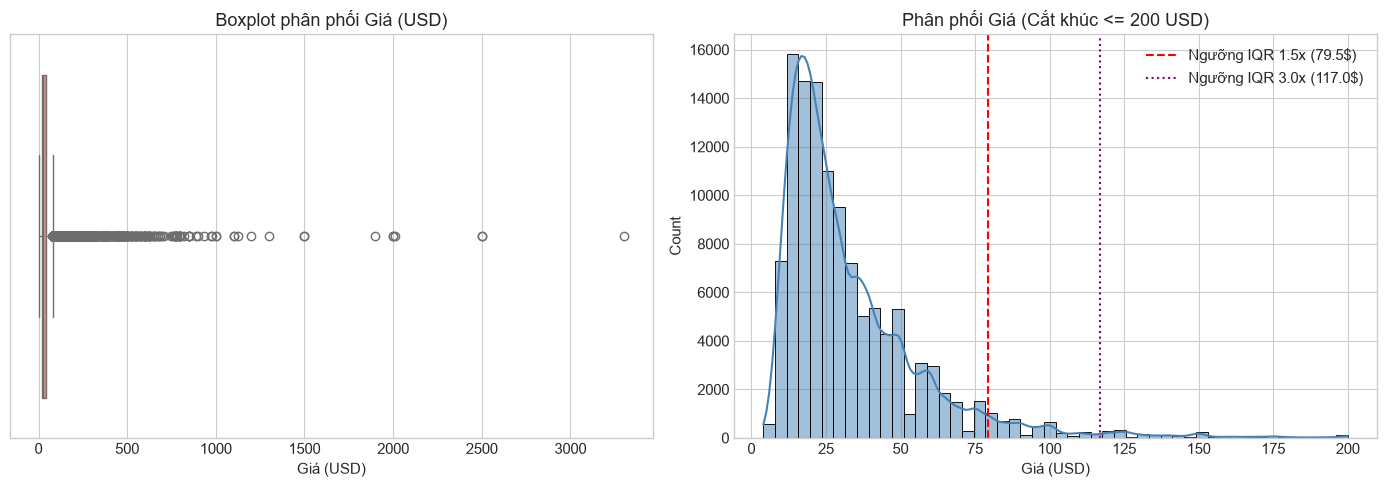

In [3]:
# Trực quan hoá phân phối giá gốc
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x=prices, ax=axes[0], color='lightcoral')
axes[0].set_title('Boxplot phân phối Giá (USD)')
axes[0].set_xlabel('Giá (USD)')

# Phân phối mật độ (giới hạn dưới 200$ để nhìn rõ thân phân phối)
sns.histplot(prices[prices <= 200], bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(mild_threshold, color='red', linestyle='--', label=f'Ngưỡng IQR 1.5x ({mild_threshold}$)')
axes[1].axvline(extreme_threshold, color='purple', linestyle=':', label=f'Ngưỡng IQR 3.0x ({extreme_threshold}$)')
axes[1].set_title('Phân phối Giá (Cắt khúc <= 200 USD)')
axes[1].set_xlabel('Giá (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Phân biệt Bản chất Outlier: Natural vs Artificial

### A. Outlier Tự nhiên Hợp lệ (Natural Outliers)
Hãy kiểm tra top các chai rượu có giá cao nhất xem chúng là chai vang nào trong thực tế thế giới rượu vang.

In [4]:
top_expensive = df[['title', 'price', 'points', 'country', 'winery']].sort_values(by='price', ascending=False).head(10)
display(top_expensive)

,title,price,points,country,winery
76317,Château les Ormes Sorbet 2013 Médoc,3300.0,88,France,Château les Ormes Sorbet
92592,Domaine du Comte Liger-Belair 2010 La Romanée,2500.0,96,France,Domaine du Comte Liger-Belair
15714,Château Pétrus 2014 Pomerol,2500.0,96,France,Château Pétrus
111765,Blair 2013 Roger Rose Vineyard Chardonnay (Arr...,2013.0,91,US,Blair
105889,Domaine du Comte Liger-Belair 2005 La Romanée,2000.0,96,France,Domaine du Comte Liger-Belair
62713,Château Pétrus 2011 Pomerol,2000.0,97,France,Château Pétrus
1558,Château Margaux 2009 Margaux,1900.0,98,France,Château Margaux
104352,Château Lafite Rothschild 2010 Pauillac,1500.0,100,France,Château Lafite Rothschild
104354,Château Cheval Blanc 2010 Saint-Émilion,1500.0,100,France,Château Cheval Blanc
1575,Château Mouton Rothschild 2009 Pauillac,1300.0,96,France,Château Mouton Rothschild


> **Nhận xét chuyên môn (Domain Insight)**:  
> - Các chai như `Domaine du Comte Liger-Belair La Romanée` ($2.500$), `Château Pétrus` ($2.000 - $2.500$), `Château Margaux` ($1.900$), `Château Lafite Rothschild` ($1.500$) đều là các dòng vang Grand Cru danh giá bậc nhất thế giới.  
> - Mức giá hàng ngàn USD là giá niêm yết thực tế. Nếu xóa bỏ các dòng này theo quy tắc thống kê máy móc (> 79.5 USD), ta sẽ làm mất toàn bộ dữ liệu phân khúc xa xỉ.  
> $\Rightarrow$ **Quyết định: Bắt buộc GIỮ LẠI các Natural Outliers này.**

### B. Outlier do Lỗi Nhập Liệu (Artificial Outliers / Data Entry Errors)
Qua kiểm tra chi tiết, ta phát hiện 2 trường hợp bất thường nghiêm trọng:

In [5]:
# Trường hợp 1: Chai Blair 2013 - Nhập nhầm năm 2013 vào cột giá
blair_error = df[df['title'].str.contains('Blair 2013 Roger Rose Vineyard', na=False)]
print("1. Lỗi nhập nhầm năm thành giá (Dòng 120391):")
display(blair_error[['title', 'price', 'points', 'winery']])

# Trường hợp 2: Château les Ormes Sorbet 2013 - Giá 3300$ trong khi điểm chỉ 88 (Cru Bourgeois thông thường giá ~33$)
ormes_error = df[df['winery'].str.contains('Ormes Sorbet', na=False)]
print("\n2. Lỗi nhầm dấu chấm thập phân 33.00 -> 3300 (Dòng 80290):")
display(ormes_error[['title', 'price', 'points', 'winery']])

1. Lỗi nhập nhầm năm thành giá (Dòng 120391):


,title,price,points,winery
111765,Blair 2013 Roger Rose Vineyard Chardonnay (Arr...,2013.0,91,Blair



2. Lỗi nhầm dấu chấm thập phân 33.00 -> 3300 (Dòng 80290):


,title,price,points,winery
76317,Château les Ormes Sorbet 2013 Médoc,3300.0,88,Château les Ormes Sorbet
88507,Château les Ormes Sorbet 2006 Médoc,22.0,87,Château les Ormes Sorbet
96177,Château les Ormes Sorbet 2011 Médoc,22.0,86,Château les Ormes Sorbet


## 4. Phân tích Outlier Đa biến: `points` vs `price`

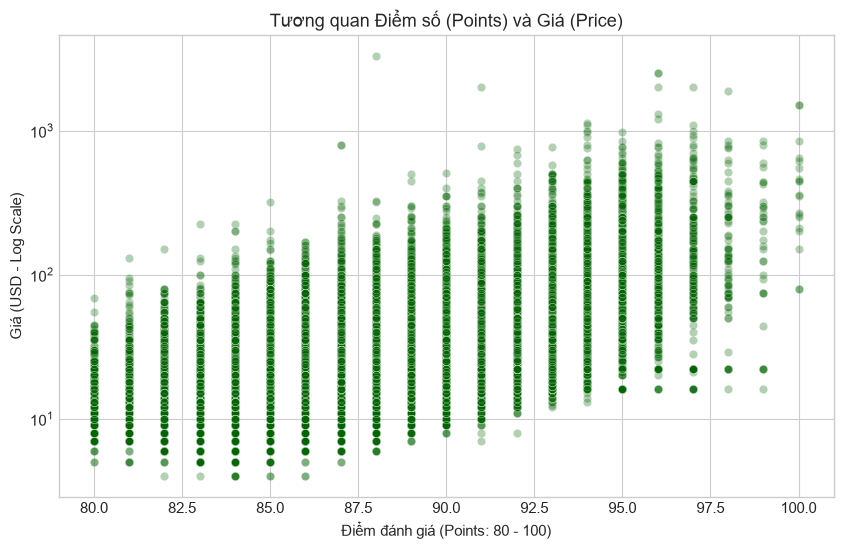

Số chai giá >= 100$ nhưng điểm <= 83: 7


,title,price,points,country,winery
11318,Espectacle 2010 René Isabelle Christopher Char...,130.0,81,Spain,Espectacle
23632,Chateau Margene 2009 Beau Melange Red (Paso Ro...,150.0,82,US,Chateau Margene
39968,Charles Lafitte 1989 Orgueil de France Brut (C...,100.0,83,France,Charles Lafitte
44538,Delectus 2012 Bear Crossing Cabernet Sauvignon...,130.0,83,US,Delectus
66788,Colomé 2012 Altura Maxima Malbec (Salta),125.0,83,Argentina,Colomé
71263,Marqués de Murrieta 1978 Castillo Ygay Gran Re...,225.0,83,Spain,Marqués de Murrieta
96589,Bellavista 1991 Vittorio Moretti Reserve Cuvée...,100.0,83,Italy,Bellavista


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='points', y='price', alpha=0.3, color='darkgreen', ax=ax)
ax.set_title('Tương quan Điểm số (Points) và Giá (Price)')
ax.set_yscale('log')  # Dùng scale log trên trục Y để dễ quan sát
ax.set_ylabel('Giá (USD - Log Scale)')
ax.set_xlabel('Điểm đánh giá (Points: 80 - 100)')
plt.show()

# Điểm thấp nhưng giá siêu cao (>= 100$ nhưng points <= 83)
high_price_low_pts = df[(df['price'] >= 100) & (df['points'] <= 83)]
print(f"Số chai giá >= 100$ nhưng điểm <= 83: {len(high_price_low_pts)}")
display(high_price_low_pts[['title', 'price', 'points', 'country', 'winery']])

## 5. Phân tích và Khử Dữ liệu Nhiễu (Noise Cleaning)

### 5.1. Khử Ký tự Lạ, HTML Entities & Khoảng trắng ẩn

In [7]:
# Đếm các trường hợp chứa HTML entities (&...;) và non-breaking space (\xa0)
html_noise = df['description'].str.contains(r'(&[a-zA-Z]+;|&#\d+;)', regex=True, na=False).sum()
nbsp_noise = df['description'].str.contains('\xa0', regex=False).sum()
print(f"Số dòng chứa HTML entities: {html_noise}")
print(f"Số dòng chứa ký tự \\xa0  : {nbsp_noise}")

Số dòng chứa HTML entities: 7
Số dòng chứa ký tự \xa0  : 0


C:\Users\pnvto\AppData\Local\Temp\ipykernel_8508\1989941222.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  html_noise = df['description'].str.contains(r'(&[a-zA-Z]+;|&#\d+;)', regex=True, na=False).sum()


### 5.2. Đánh giá Siêu ngắn (Non-informative Review Noise)

In [8]:
word_counts = df['description'].apply(lambda x: len(str(x).split()))
short_reviews = df[word_counts < 10]
print(f"Số lượng review dưới 10 từ: {len(short_reviews)} dòng")
print("Mẫu các review không có nội dung cảm quan:")
display(short_reviews[['title', 'description', 'points']].head(5))

Số lượng review dưới 10 từ: 39 dòng
Mẫu các review không có nội dung cảm quan:


,title,description,points
3624,YN NV Red (California),"Sugary sweet and medicinal, like cherry cough ...",81
3628,Melrose 2010 Pinot Noir (Umpqua Valley),"Dilute, with simple strawberry flavors and a d...",81
9443,Strait Jacket 2007 Sauvignon Blanc-Semillon (W...,Imported by Bluewater Wine Company.,87
12931,Naches Heights 2006 Riesling (Columbia Valley ...,"Flat, fruity and lacking in complexity.",82
12942,Naches Heights 2006 Pinot Gris (Columbia Valle...,"A flat tasting, slightly sweet, generic white ...",81


### 5.3. Khử Nhiễu Năm Thành Lập khi Trích xuất Niên Vụ (Vintage Year)

In [9]:
def extract_clean_vintage(title):
    if not isinstance(title, str):
        return np.nan
    # Nếu là vang không niên vụ (NV)
    if re.search(r'\b(NV|Non-Vintage)\b', title, re.IGNORECASE):
        return np.nan
    match = re.search(r'\b(19\d\d|20[0-2]\d)\b', title)
    if match:
        year = int(match.group(1))
        if 1980 <= year <= 2021:
            return float(year)
    return np.nan

vintages = df['title'].apply(extract_clean_vintage)
print(f"Số chai trích xuất được niên vụ chuẩn: {vintages.notna().sum():,} / {len(df):,}")
print(f"Khoảng niên vụ: {vintages.min():.0f} - {vintages.max():.0f}")

Số chai trích xuất được niên vụ chuẩn: 115,660 / 119,988
Khoảng niên vụ: 1980 - 2017


## 6. Thực hiện Làm Sạch & Biến đổi Log-transform (Before vs After)

Áp dụng hàm chuẩn hoá từ module `src/handle_outliers_and_noise.py`.

In [10]:
import sys
sys.path.append(str(PROJECT_ROOT))
from src.handle_outliers_and_noise import process_dataset

df_cleaned, actions = process_dataset(df)
print("=== BÁO CÁO HÀNH ĐỘNG XỬ LÝ ===")
for action, count in actions.items():
    print(f"- {action}: {count}")

=== BÁO CÁO HÀNH ĐỘNG XỬ LÝ ===
- price_stats_before: {'valid_count': 119988, 'missing_count': 0, 'mean': 35.13660532719938, 'median': 25.0, 'q1': 17.0, 'q3': 42.0, 'iqr': 25.0, 'mild_threshold': 79.5, 'extreme_threshold': 117.0, 'mild_outliers_count': 6873, 'mild_outliers_pct': 5.7280728072807285, 'extreme_outliers_count': 2574, 'extreme_outliers_pct': 2.145214521452145, 'over_500_count': 91, 'over_1000_count': 14, 'skewness_raw': 18.398934914745812}
- short_reviews_flagged: 39
- vintages_extracted: 115660
- corrections: {'blair_2013': 1, 'chateau_ormes_sorbet': 1}
- skewness_after_log: 0.6725910991369455


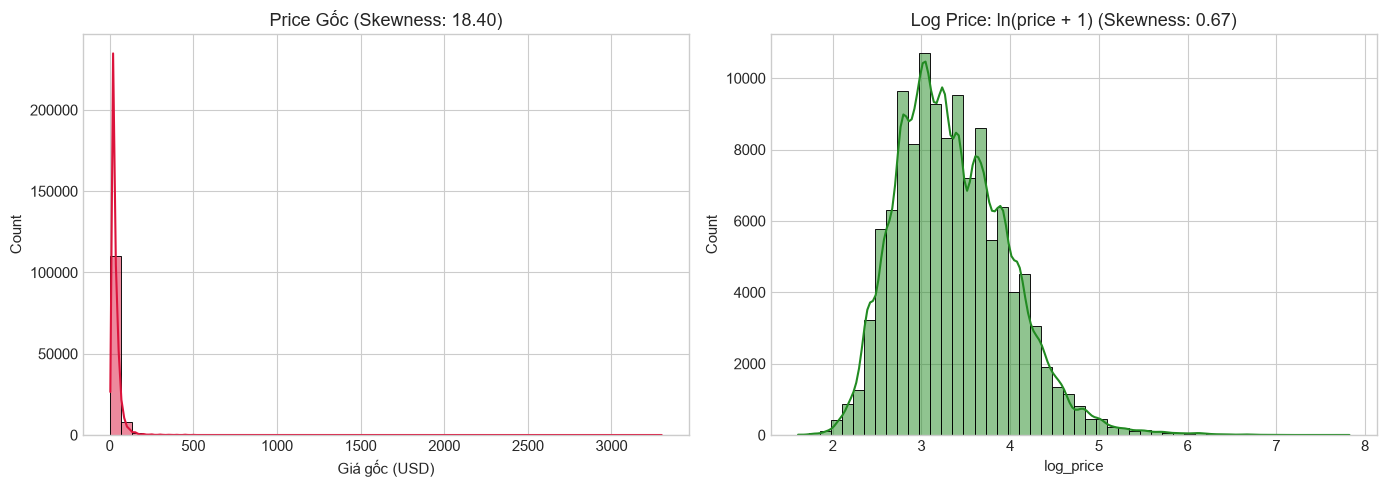

In [11]:
# So sánh phân phối Before vs After Log Transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối trước biến đổi
sns.histplot(df['price'].dropna(), bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title(f"Price Gốc (Skewness: {df['price'].skew():.2f})")
axes[0].set_xlabel('Giá gốc (USD)')

# Phân phối sau log-transform
sns.histplot(df_cleaned['log_price'].dropna(), bins=50, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f"Log Price: ln(price + 1) (Skewness: {df_cleaned['log_price'].skew():.2f})")
axes[1].set_xlabel('log_price')

plt.tight_layout()
plt.show()

## 7. Kết luận và Khuyến nghị

1. **Bảo toàn dữ liệu giá trị cao**: Toàn bộ 6.873 giá trị giá vượt ngưỡng IQR ($79.5 - $2.500) được giữ lại nguyên vẹn.
2. **Hiệu chỉnh có lưu vết**: Đã hiệu chỉnh 2 trường hợp gõ nhầm giá cực đoan ($2.013\$$ thành $35\$$ và $3.300\$$ thành $33\$$).
3. **Khử sạch Noise**: Đã làm sạch ký tự HTML, loại bỏ ký tự lạ `\xa0`, gắn nhãn 39 review ít thông tin và khử nhiễu năm thành lập khi trích xuất niên vụ.
4. **Tối ưu cho Machine Learning**: Cột `log_price` giảm độ lệch phân phối từ **18.40** xuống còn **0.67**, đưa biến giá về phân phối gần chuẩn lý tưởng.